In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

file = 'names.txt'
words = open(file, 'r').read().splitlines()
print(words[:8])
print(len(words))
print(max(len(w) for w in words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033
15


In [2]:
chars = sorted(list(set(''.join(words))))
print(chars)
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [3]:
import random
random.seed(42)
random.shuffle(words)

In [42]:
block_size = 8  # context length: how many characters do we take to predict next?
def build_dataset(words):    
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix]    # shift one charater to the left and append the new character

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182424, 8]) torch.int64 torch.Size([182424]) torch.int64
torch.Size([22836, 8]) torch.int64 torch.Size([22836]) torch.int64
torch.Size([22886, 8]) torch.int64 torch.Size([22886]) torch.int64


In [43]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '---->', itos[y.item()])

........ ----> n
.......n ----> y
......ny ----> r
.....nyr ----> e
....nyre ----> e
...nyree ----> .
........ ----> e
.......e ----> d
......ed ----> i
.....edi ----> e
....edie ----> .
........ ----> c
.......c ----> o
......co ----> a
.....coa ----> l
....coal ----> s
...coals ----> o
..coalso ----> n
.coalson ----> .
........ ----> s


In [81]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn(fan_in, fan_out) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with BP)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (updated with a moving average)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):     
        if self.training:
            # calculate batch statistics
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            # xmean = x.mean(0, keepdim=True) # bug exists if FlattenConsecutive() is used as x is assumed to be 2D
            # xvar = x.var(0, keepdim=True)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
            
        else:
            # use running statistics at inference time
            xmean = self.running_mean
            xvar = self.running_var
        # apply batch normalization
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar 
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn(num_embeddings, embedding_dim)
        
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

# class Flatten:
#     def __call__(self, x):
#         self.out = x.view(x.shape[0], -1)
#         return self.out
    
#     def parameters(self):
#         return []
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
    
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n , C * self.n)     # // mean divide and round down
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [7]:
torch.manual_seed(42);

In [96]:
n_embd = 30  # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

#C = torch.randn(vocab_size, n_embd) # the embedding table
# layers = [
#     Embedding(vocab_size, n_embd), 
#     Flatten(),
#     Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, vocab_size)
# ]
model = Sequential([
    Embedding(vocab_size, n_embd), 
    #Flatten(),
    FlattenConsecutive(2),
    #Linear(n_embd * block_size, n_hidden, bias=False), 
    Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),       # new lines
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

# paramater init
with torch.no_grad():
    model.layers[-1].weight *= 0.1
#parameters = [C] + [p for layer in layers for p in layer.parameters()]
#parameters = [p for layer in layers for p in layer.parameters()]
parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

179437


In [70]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 20, 18,  5, 25],
        [ 0,  0,  0,  0,  1, 14, 20,  1],
        [ 0,  0,  0,  0,  0,  4,  1, 14],
        [ 0,  0,  0,  0,  0,  0,  0,  0]])

In [84]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))
print('logits.shape:', logits.shape)

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)
logits.shape: torch.Size([32, 27])


In [85]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [ ]:
print(model.layers[0].out.shape)        # Embedding layer
print(model.layers[1].out.shape)        # Flatten layer
print(model.layers[2].out.shape)        # Linear layer (before nonlinearity)

torch.Size([4, 8, 10])
torch.Size([4, 80])
torch.Size([4, 200])


In [ ]:
# Noted that
(torch.randn(4, 5, 2, 80) @ torch.randn(80, 200) + torch.randn(200)).shape
# The matrix multiplication is performed on the last dimensions of the first tensor and the first dimension of the second tensor

torch.Size([4, 5, 2, 200])

In [ ]:
# (1 2) (3 4) (5 6) (7 8) grouped into 4 groups of 2
#(torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape
(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape

In [54]:
print(list(range(10)))
print(list(range(10))[::2])
print(list(range(10))[1::2])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 2, 4, 6, 8]
[1, 3, 5, 7, 9]


In [59]:
e = torch.randn(4, 8, 10) # goal: want this to be (4, 4, 20) where consecutive 10-d vectors get concatenated together
explicit = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)
print(explicit.shape)
(e.view(4, 4, 20) == explicit).all()

torch.Size([4, 4, 20])


tensor(True)

In [ ]:
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True) # 1, 4, 68
evar = e.var(0, keepdim=True)   # 1, 4, 68
ehat = (e - emean) / torch.sqrt(evar + 1e-5) #32, 4, 68
print(emean.shape, evar.shape, ehat.shape)
# This maintaining the 4 independently = the mean and var are not correct

# Therefore:
e = torch.randn(32, 4, 68)
emean = e.mean((0, 1), keepdim=True) # 1, 1, 68
evar = e.var((0, 1), keepdim=True)   # 1, 1, 68
ehat = (e - emean) / torch.sqrt(evar + 1e-5) #32, 4, 68
print(emean.shape, evar.shape, ehat.shape)

torch.Size([1, 4, 68]) torch.Size([1, 4, 68]) torch.Size([32, 4, 68])
torch.Size([1, 1, 68]) torch.Size([1, 1, 68]) torch.Size([32, 4, 68])


In [97]:
max_steps = 200000       # max step + 1
step_track = int(f"{(max_steps - 1):e}".split('e')[1]) - 1
batch_size = 64
lossi = []

for i in range(max_steps):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) 
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    # emb = C[Xb]
    # x = emb.view(emb.shape[0], -1)
    # x = Xb
    # for layer in layers:
    #     x = layer(x)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % (10 ** step_track) == 0:
        print(f'{i:7d}/{max_steps - 1}: {loss.item():.4f}')
    #lossi.append((i, loss.log().item()))
    lossi.append(loss.log10().item())

    #break

      0/199999: 3.2813
  10000/199999: 1.8489
  20000/199999: 2.1140
  30000/199999: 2.1183
  40000/199999: 1.7492
  50000/199999: 2.1387
  60000/199999: 2.0574
  70000/199999: 2.0073
  80000/199999: 1.5783
  90000/199999: 1.7500
 100000/199999: 1.7983
 110000/199999: 1.9110
 120000/199999: 2.1479
 130000/199999: 1.7230
 140000/199999: 1.4860
 150000/199999: 1.5157
 160000/199999: 1.6059
 170000/199999: 1.5787
 180000/199999: 1.6867
 190000/199999: 1.4829


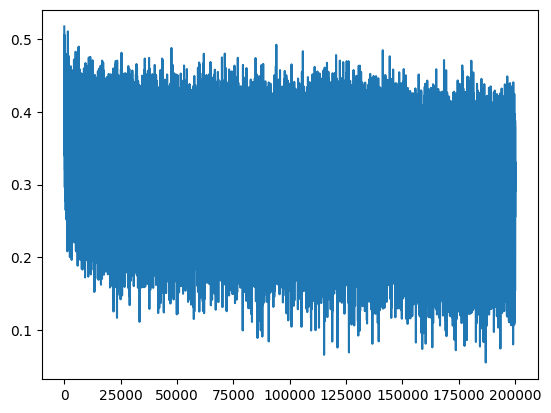

In [88]:
# plt.plot([x[0] for x in lossi], [x[1] for x in lossi])
# plt.xlabel('Step')
# plt.ylabel('Loss')
# plt.title('Training Loss')
plt.plot(lossi)

torch.Size([200, 1000])
torch.Size([200])


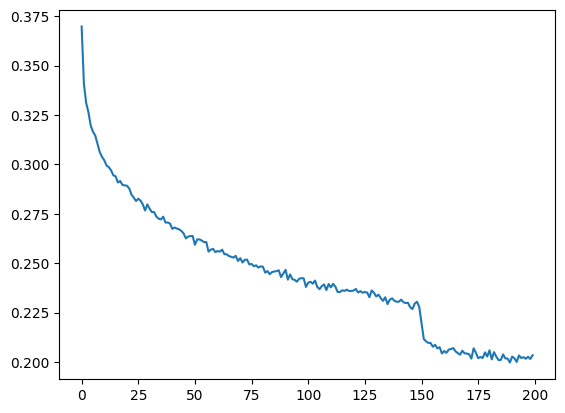

In [98]:
print(torch.tensor(lossi).view(-1, 1000).shape)
print(torch.tensor(lossi).view(-1, 1000).mean(1).shape)
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))


In [36]:
torch.arange(10).view(-1, 5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [99]:
for layer in model.layers:
    layer.training = False      # same as network.eval()

@torch.no_grad()
def split_loss(split):
    x, y ={
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    logits = model(x)
    # emb = C[x]
    # x = emb.view(emb.shape[0], -1)
    # for layer in layers:
    #     x = layer(x)
    # loss = F.cross_entropy(x, y)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')
split_loss('test')

train loss: 1.5659
val loss: 2.0719
test loss: 2.0852


performance log

- original (3 char context + 200 hidden neurons, 12k parameters): train 2.0573, val 2.1056.
- context 3 -> 8 (22k parameters): train 1.9201, val 2.0307
- flat -> hierarchical (22k parameters): train 1.9375 val 2.0330
- fix bug in batchnorm: train 1.9108, val 2.0261
- scale up the network n_emb 24, n_hidden 128 (76k parameters): train 1.7669, val 1.9903
- scale up the network n_emb 30, n_hidden 200: train 1.5659m, val 2.0719

In [100]:
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        #emb = C[torch.tensor([context])]
        logits = model(torch.tensor([context]))
        # embcat = emb.view(1, -1)
        # x = emb.view(emb.shape[0], -1)
        # for layer in layers:
        #     x = layer(x)
        # probs = F.softmax(x, dim=1)        # No need take log, so softmax is enough
        probs = F.softmax(logits, dim=1)     
        ix = torch.multinomial(probs, num_samples=1).item()
        out.append(ix)
        context = context[1:] + [ix]
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))
    with open('generated_names_5layers.txt', 'a') as f:
        f.write(''.join(itos[i] for i in out) + '\n')

alayza.
neave.
aveen.
maddelynn.
tyon.
metzs.
korrin.
abhi.
aspyn.
henos.
karson.
legaci.
jamillia.
tovia.
tal.
jarelys.
ayslee.
alexandro.
koah.
iwan.


HW1: Understand the concepts and tidy up to a py script.
HW2: Use nn.torch to reproduce the HW1. 